# ✈️ Clustering Airline Customer Segmentation

**Problem:** Maskapai penerbangan 'X' ingin mengetahui bagaimana daya tanggap pelanggan agar dapat merencanakan strategi campaign yang sesuai dengan habit para pelanggan. Namun pihak maskapai kesulitan untuk merencanakan strategi campaign karena habit pelanggan mereka yang beragam.

**Goals:** Strategi campaign yang tepat sasaran, sesuai dengan habit pelanggan.

**Objective:** Customer Segmentation menggunakan pendekatan **LRFMC** (Length, Recency, Frequency, Monetary, Class).

**Business Metrics:** Segmentasi pelanggan berdasarkan LRFMC.

---
Sebenarnya kita menggunakan metode utamanya adalah RFM. Apa itu RFM?

Analisis RFM adalah metode pemasaran untuk mengelompokkan pelanggan berdasarkan perilaku belanja: Recency (seberapa baru), Frequency (seberapa sering), dan Monetary (berapa banyak uang yang dihabiskan). Teknik ini mengidentifikasi pelanggan paling bernilai (VIP), berisiko tinggi, atau loyalis untuk meningkatkan retensi dan penjualan yang personal. 

Namun, di sini kita menambah dua fitur yaitu L dan C agar kita bisa melihat perliaku customer secara lebih detail

### Penjelasan LRFMC
| Inisial | Nama | Kolom Sumber | Penjelasan |
|---------|------|-------------|------------|
| **L** | Length | `LOAD_TIME - FFP_DATE` | Berapa lama customer menjadi anggota (dalam bulan) |
| **R** | Recency | `LAST_TO_END` | Jarak waktu sejak penerbangan terakhir (dalam hari) |
| **F** | Frequency | `FLIGHT_COUNT` | Seberapa sering customer bertransaksi |
| **M** | Monetary | `SEG_KM_SUM` | Total jarak (KM) yang sudah ditempuh |
| **C** | Class | `avg_discount` | Rata-rata diskon yang didapat (proxy kelas tiket) |

---
## 1. Data Preprocessing

Pada tahap ini kita akan:
1. Import library yang dibutuhkan
2. Memuat dataset dan inspeksi awal
3. Menghitung fitur LRFMC
4. Menangani missing values dan outlier

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


### 1.1 Load Dataset & Inspeksi Awal

In [2]:
# Load dataset
df = pd.read_csv('../dataset/flight.csv')
print(f'Dataset shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]:,}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()

Dataset shape: (62988, 23)
Jumlah baris: 62,988
Jumlah kolom: 23


,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
0,54993,11/2/2006,12/24/2008,Male,6,.,beijing,CN,31.0,3/31/2014,...,234188.0,580717,3/31/2014,1,3.483254,18,34,0.961639,619760,50
1,28065,2/19/2007,8/3/2007,Male,6,NaN,beijing,CN,42.0,3/31/2014,...,167434.0,293678,3/25/2014,7,5.194245,17,29,1.252314,415768,33
2,55106,2/1/2007,8/30/2007,Male,6,.,beijing,CN,40.0,3/31/2014,...,164982.0,283712,3/21/2014,11,5.298507,18,20,1.254676,406361,26
3,21189,8/22/2008,8/23/2008,Male,5,Los Angeles,CA,US,64.0,3/31/2014,...,125500.0,281336,12/26/2013,97,27.863636,73,11,1.090870,372204,12
4,39546,4/10/2009,4/15/2009,Male,6,guiyang,guizhou,CN,48.0,3/31/2014,...,130702.0,309928,3/27/2014,5,4.788079,47,27,0.970658,338813,39


In [3]:
# Cek tipe data dan info umum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [4]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
missing_df[missing_df['Missing Count'] > 0]

=== Missing Values ===


,Missing Count,Missing %
GENDER,3,0.00
WORK_CITY,2269,3.60
WORK_PROVINCE,3248,5.16
WORK_COUNTRY,26,0.04
AGE,420,0.67
SUM_YR_1,551,0.87
SUM_YR_2,138,0.22


**Insight:**
- Dataset memiliki 62.988 baris dan 23 kolom.
- Missing values utamanya ada pada kolom kategorik (`WORK_CITY`, `WORK_PROVINCE`) dan `SUM_YR_1/2`, serta sedikit di `AGE` dan `GENDER`.
- Karena kita hanya akan menggunakan fitur-fitur **LRFMC** (`FFP_DATE`, `LOAD_TIME`, `LAST_TO_END`, `FLIGHT_COUNT`, `SEG_KM_SUM`, `avg_discount`), missing values pada kolom lain tidak akan mempengaruhi analisis kita.

### 1.2 Menghitung Fitur LRFMC

In [5]:
# Konversi kolom tanggal ke datetime
df['FFP_DATE'] = pd.to_datetime(df['FFP_DATE'])
df['LOAD_TIME'] = pd.to_datetime(df['LOAD_TIME'])

# Hitung fitur L (Length) — lama menjadi member dalam bulan
# Menggunakan days / 30 sebagai pendekatan jumlah bulan
# Ini adalah konvensi umum di analisis RFM/LRFMC karena tujuannya adalah mendapat
# skala yang mudah diinterpretasi (bulan), bukan presisi kalender yang eksak.
df['L'] = (df['LOAD_TIME'] - df['FFP_DATE']).dt.days / 30


print('📅 Contoh perhitungan L (Length):')
print(df[['FFP_DATE', 'LOAD_TIME', 'L']].head())
print(f'\nRata-rata L: {df["L"].mean():.1f} bulan')
print(f'Range L: {df["L"].min():.1f} - {df["L"].max():.1f} bulan')

📅 Contoh perhitungan L (Length):
    FFP_DATE  LOAD_TIME          L
0 2006-11-02 2014-03-31  90.200000
1 2007-02-19 2014-03-31  86.566667
2 2007-02-01 2014-03-31  87.166667
3 2008-08-22 2014-03-31  68.233333
4 2009-04-10 2014-03-31  60.533333

Rata-rata L: 49.5 bulan
Range L: 12.2 - 114.6 bulan


> **Catatan tentang perhitungan L:**
> Kita membagi selisih hari dengan 30 sebagai **pendekatan** jumlah bulan. Ini bukan perhitungan bulan kalender yang tepat (karena tidak semua bulan tepat 30 hari), tetapi ini adalah konvensi yang sangat umum di analisis LRFMC/RFM karena:
> 1. Tujuannya adalah mendapat **skala relatif** antar customer, bukan angka bulan yang presisi
> 2. Hasilnya lebih mudah diinterpretasi daripada hari
> 3. Perbedaan 1-3 hari per bulan tidak signifikan untuk segmentasi

In [6]:
# Pilih 5 fitur utama LRFMC
df_lrfmc = df[['L', 'LAST_TO_END', 'FLIGHT_COUNT', 'SEG_KM_SUM', 'avg_discount']].copy()
df_lrfmc.columns = ['L', 'R', 'F', 'M', 'C']

print('=== LRFMC Features ===')
print(f'Shape: {df_lrfmc.shape}')
print(f'\nMissing values:')
print(df_lrfmc.isnull().sum())
print(f'\n✅ Tidak ada missing values pada 5 fitur LRFMC!')
df_lrfmc.head(10)

=== LRFMC Features ===
Shape: (62988, 5)

Missing values:
L    0
R    0
F    0
M    0
C    0
dtype: int64

✅ Tidak ada missing values pada 5 fitur LRFMC!


,L,R,F,M,C
0,90.200000,1,210,580717,0.961639
1,86.566667,7,140,293678,1.252314
2,87.166667,11,135,283712,1.254676
3,68.233333,97,23,281336,1.090870
4,60.533333,5,152,309928,0.970658
5,74.700000,79,92,294585,0.967692
6,97.700000,1,101,287042,0.965347
7,48.400000,3,73,287230,0.962070
8,34.266667,6,56,321489,0.828478
9,45.500000,15,64,375074,0.708010


In [7]:
# Descriptive statistics dari fitur LRFMC sebelum treatment
print('=== Statistik Deskriptif LRFMC (Sebelum Outlier Treatment) ===')
df_lrfmc.describe().round(2)

=== Statistik Deskriptif LRFMC (Sebelum Outlier Treatment) ===


,L,R,F,M,C
count,62988.00,62988.00,62988.00,62988.00,62988.00
mean,49.50,176.12,11.84,17123.88,0.72
std,28.24,183.82,14.05,20960.84,0.19
min,12.17,1.00,2.00,368.00,0.00
25%,24.40,29.00,3.00,4747.00,0.61
50%,42.33,108.00,7.00,9994.00,0.71
75%,72.63,268.00,15.00,21271.25,0.81
max,114.57,731.00,213.00,580717.00,1.50


### 1.3 Handling Outliers

Kita menggunakan metode **Percentile Capping (1%–99%)** untuk menangani outlier. 

**Mengapa Percentile Capping?**
1. **Preservasi data**: Dengan capping kita tidak kehilangan data point. Setiap customer tetap dihitung — hanya nilai ekstremnya yang di-cap ke batas wajar.
2. **Konsisten & data-driven**: Percentile capping selalu memangkas tepat 2% data (1% terbawah + 1% teratas) pada setiap fitur, sehingga hasilnya lebih konsisten dan proporsional dibanding metode IQR yang batasnya bisa terlalu lebar atau terlalu sempit pada distribusi yang skewed.
3. **Lebih efektif untuk data LRFMC**: Data penerbangan (terutama fitur F dan M) sering memiliki distribusi **right-skewed** yang ekstrem. IQR cenderung menghasilkan batas atas yang terlalu longgar pada distribusi seperti ini, sehingga outlier tetap lolos. Percentile capping langsung membatasi berdasarkan posisi aktual dalam distribusi data.
4. **Mengurangi pengaruh nilai ekstrem**: Extreme values yang lolos dari capping dapat mendominasi perhitungan jarak di K-Means, menyebabkan cluster tidak seimbang.

In [8]:
# Outlier detection & capping menggunakan Percentile method (1%-99%)
def cap_outliers_percentile(df, columns, lower_pct=0.01, upper_pct=0.99):
    """
    Cap outlier menggunakan metode Percentile.
    Nilai di bawah percentile 1% di-cap ke lower bound.
    Nilai di atas percentile 99% di-cap ke upper bound.
    """
    df_capped = df.copy()
    summary = []
    
    for col in columns:
        lower = df[col].quantile(lower_pct)
        upper = df[col].quantile(upper_pct)
        
        n_outliers_low = (df[col] < lower).sum()
        n_outliers_high = (df[col] > upper).sum()
        
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
        
        summary.append({
            'Feature': col,
            'P1 (1%)': round(lower, 2),
            'P99 (99%)': round(upper, 2),
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outliers Low': n_outliers_low,
            'Outliers High': n_outliers_high,
            'Total Outliers': n_outliers_low + n_outliers_high
        })
    
    return df_capped, pd.DataFrame(summary)

# Apply capping
df_lrfmc_capped, outlier_summary = cap_outliers_percentile(df_lrfmc, df_lrfmc.columns)

print('=== Outlier Summary (Percentile 1%-99% Method) ===')
outlier_summary

=== Outlier Summary (Percentile 1%-99% Method) ===


,Feature,P1 (1%),P99 (99%),Lower Bound,Upper Bound,Outliers Low,Outliers High,Total Outliers
0,L,12.63,110.80,12.63,110.80,621,629,1250
1,R,1.00,687.00,1.00,687.00,0,617,617
2,F,2.00,69.00,2.00,69.00,0,627,627
3,M,1190.00,100841.28,1190.00,100841.28,624,630,1254
4,C,0.33,1.41,0.33,1.41,630,607,1237


In [9]:
# Perbandingan sebelum dan sesudah capping
print('=== Statistik SEBELUM Capping ===')
display(df_lrfmc.describe().round(2))

print('\n=== Statistik SESUDAH Capping ===')
display(df_lrfmc_capped.describe().round(2))

=== Statistik SEBELUM Capping ===


,L,R,F,M,C
count,62988.00,62988.00,62988.00,62988.00,62988.00
mean,49.50,176.12,11.84,17123.88,0.72
std,28.24,183.82,14.05,20960.84,0.19
min,12.17,1.00,2.00,368.00,0.00
25%,24.40,29.00,3.00,4747.00,0.61
50%,42.33,108.00,7.00,9994.00,0.71
75%,72.63,268.00,15.00,21271.25,0.81
max,114.57,731.00,213.00,580717.00,1.50



=== Statistik SESUDAH Capping ===


,L,R,F,M,C
count,62988.00,62988.00,62988.00,62988.00,62988.00
mean,49.48,175.93,11.63,16757.99,0.72
std,28.20,183.29,12.81,18565.70,0.18
min,12.63,1.00,2.00,1190.00,0.33
25%,24.40,29.00,3.00,4747.00,0.61
50%,42.33,108.00,7.00,9994.00,0.71
75%,72.63,268.00,15.00,21271.25,0.81
max,110.80,687.00,69.00,100841.28,1.41


---
## 2. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan menganalisis distribusi setiap fitur LRFMC, mengecek normalitas, dan melihat hubungan antar fitur.

### 2.1 Distribusi, Q-Q Plot, dan Boxplot per Fitur


📈 Distribusi Data SEBELUM Outlier Capping:


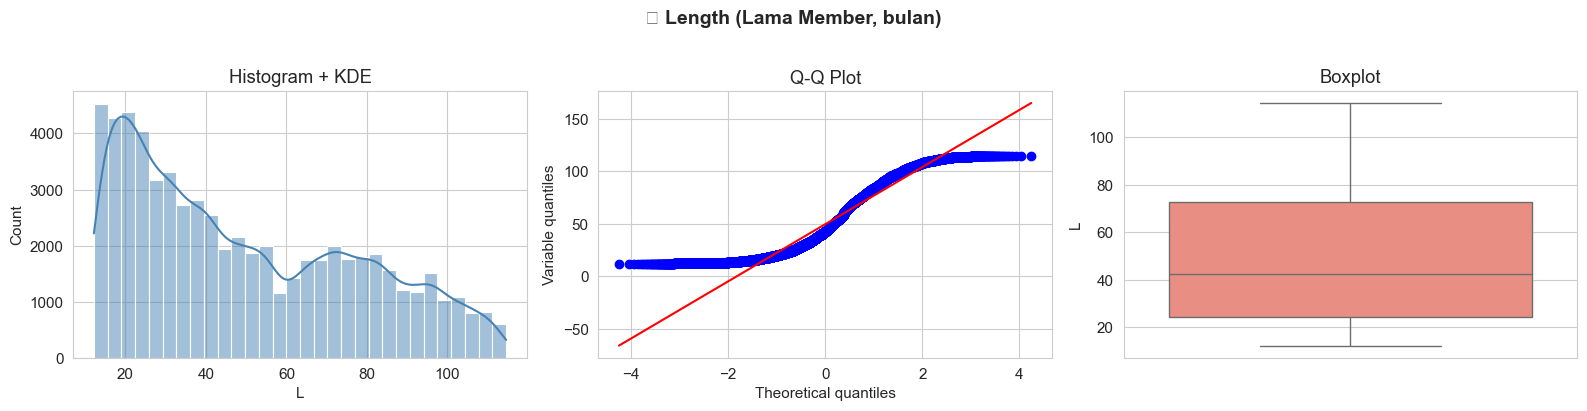

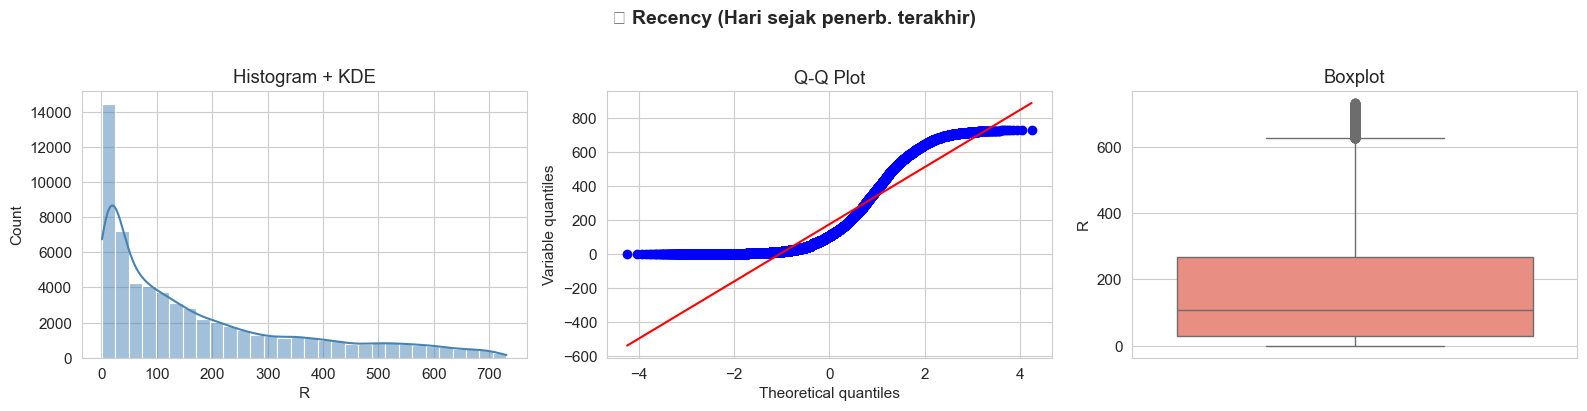

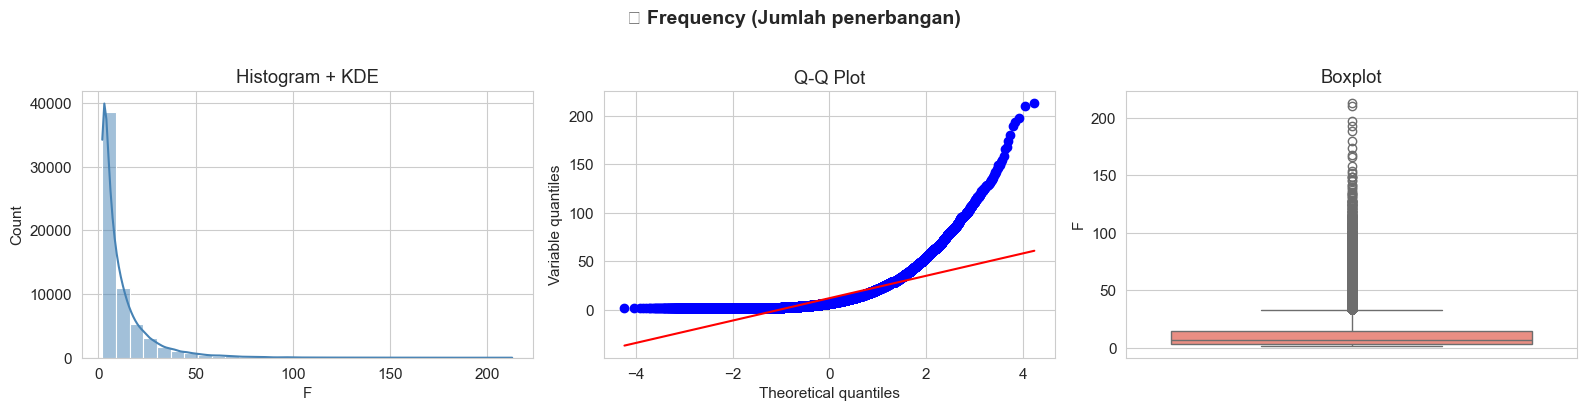

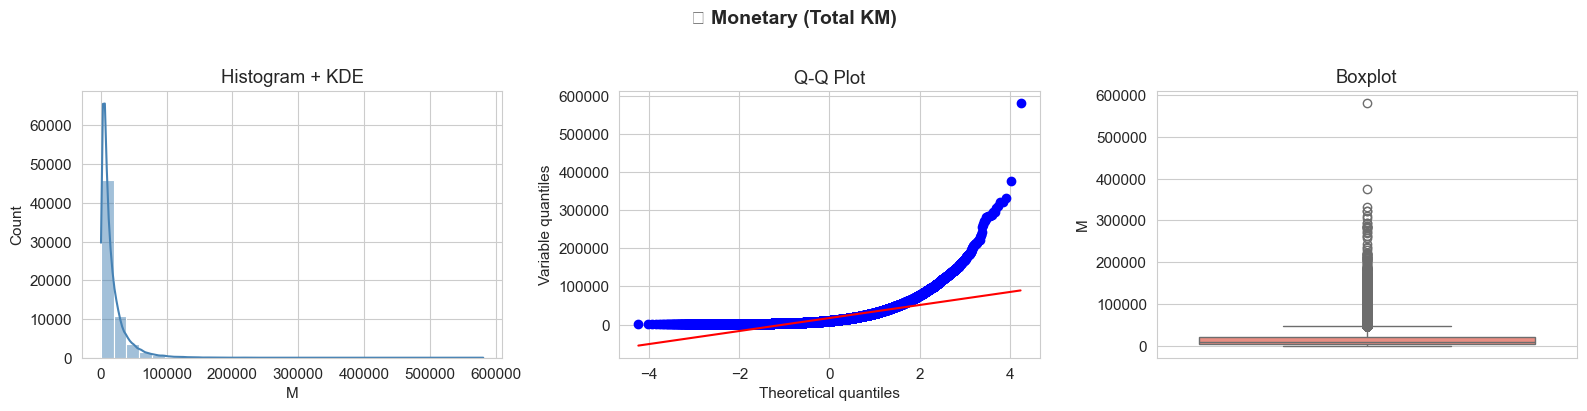

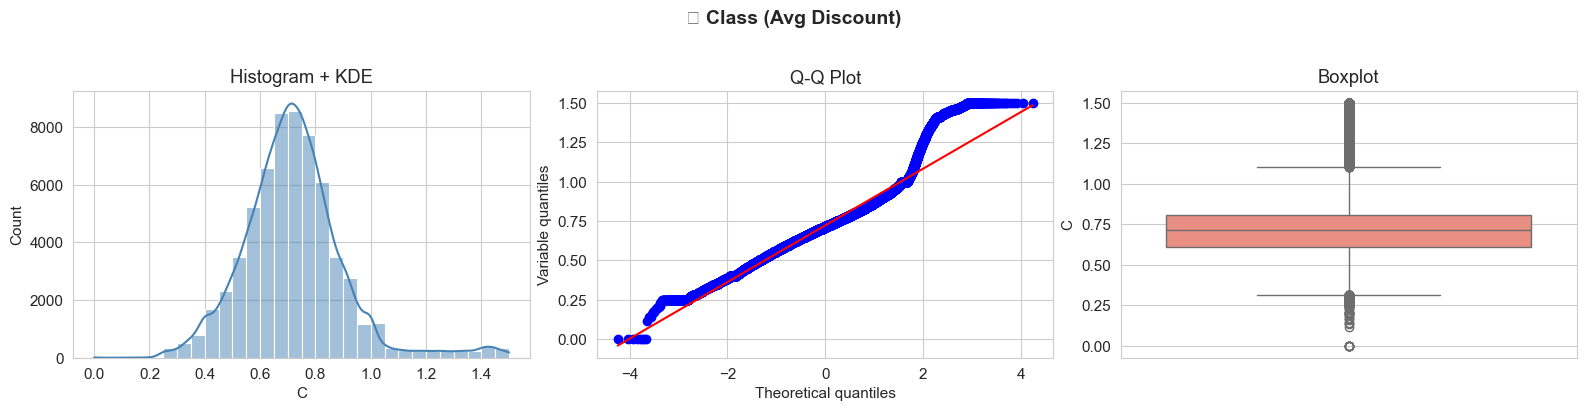

In [10]:
# Fungsi untuk plot distribusi, Q-Q, dan boxplot sekaligus
cek_kolom = ['L', 'R', 'F', 'M', 'C']
nama_fitur = {
    'L': 'Length (Lama Member, bulan)',
    'R': 'Recency (Hari sejak penerb. terakhir)',
    'F': 'Frequency (Jumlah penerbangan)',
    'M': 'Monetary (Total KM)',
    'C': 'Class (Avg Discount)'
}

def check_plot(df, columns):
    for variable in columns:
        plt.figure(figsize=(16, 4))
        plt.suptitle(f'📊 {nama_fitur.get(variable, variable)}', fontsize=14, fontweight='bold', y=1.02)
        
        # Histogram
        plt.subplot(1, 3, 1)
        sns.histplot(df[variable], bins=30, kde=True, color='steelblue')
        plt.title('Histogram + KDE')
        plt.xlabel(variable)
        
        # Q-Q Plot
        plt.subplot(1, 3, 2)
        stats.probplot(df[variable], dist="norm", plot=plt)
        plt.title('Q-Q Plot')
        plt.ylabel('Variable quantiles')
        
        # Box Plot
        plt.subplot(1, 3, 3)
        sns.boxplot(y=df[variable], color='salmon')
        plt.title('Boxplot')
        
        plt.tight_layout()
        plt.show()

print('📈 Distribusi Data SEBELUM Outlier Capping:')
check_plot(df_lrfmc, cek_kolom)

**Insight dari distribusi:**
- **L (Length)**: Distribusi cenderung left-skewed, mayoritas customer sudah cukup lama menjadi member.
- **R (Recency)**: Right-skewed — sebagian besar customer belakangan ini aktif terbang (recency rendah), tetapi ada juga yang sudah lama tidak terbang.
- **F (Frequency)**: Sangat right-skewed — kebanyakan customer memiliki jumlah penerbangan yang rendah, sedikit yang sangat sering terbang.
- **M (Monetary)**: Mirip distribusi F, right-skewed — mayoritas KM rendah.
- **C (Class/Discount)**: Mendekati normal, puncak di sekitar 0.7 — artinya mayoritas customer mendapat diskon moderate.

Dari Q-Q plot terlihat bahwa sebagian besar fitur **tidak berdistribusi normal**, tapi ini **tidak masalah** karena K-Means tidak memerlukan asumsi normalitas. K-Means hanya memerlukan data numerik dan bekerja berdasarkan jarak (Euclidean distance).

📈 Distribusi Data SETELAH Outlier Capping:


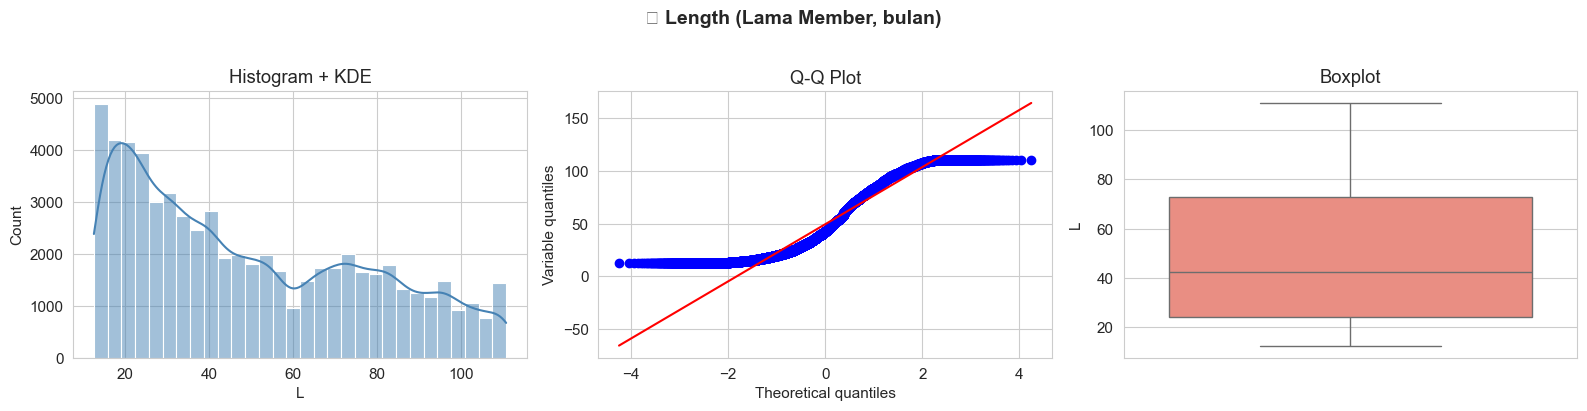

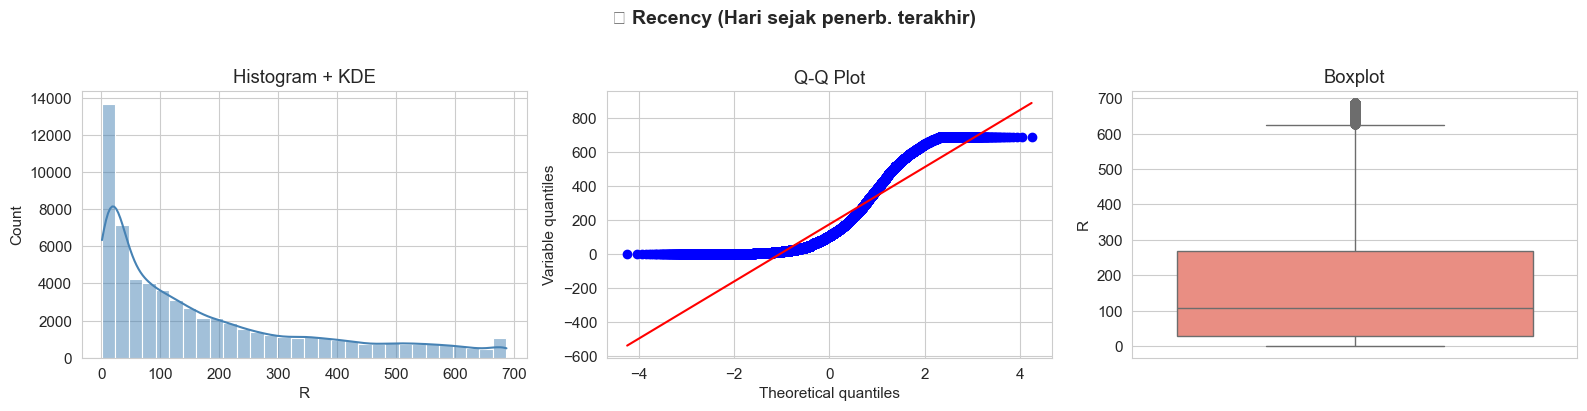

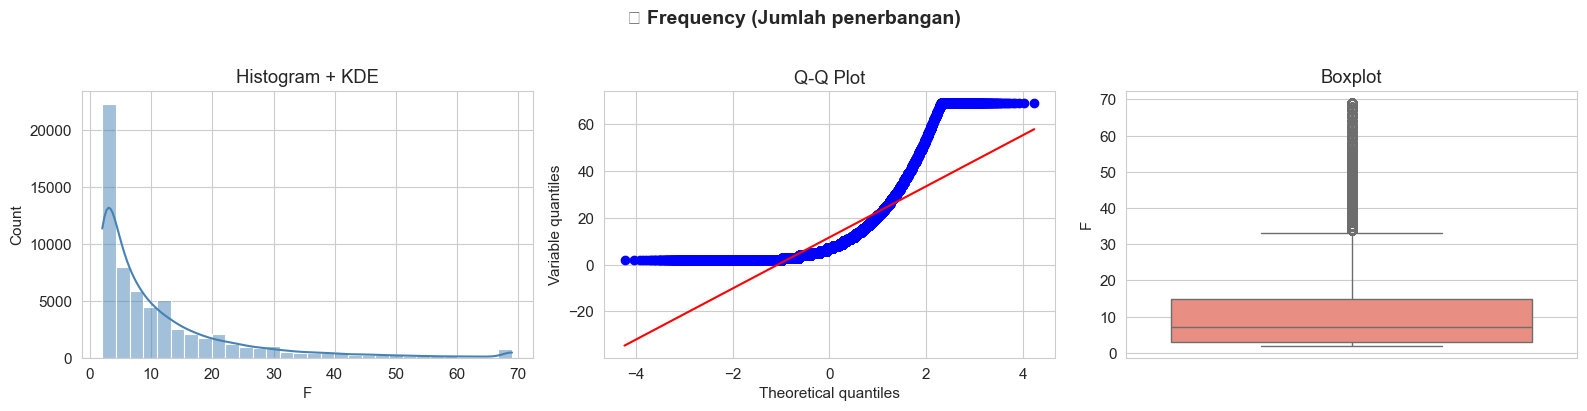

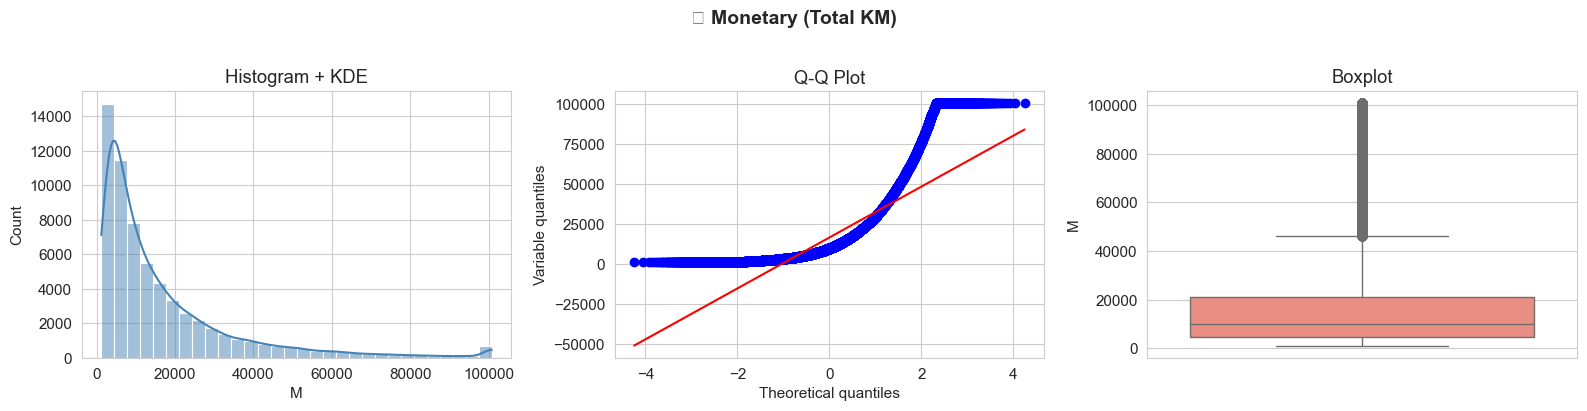

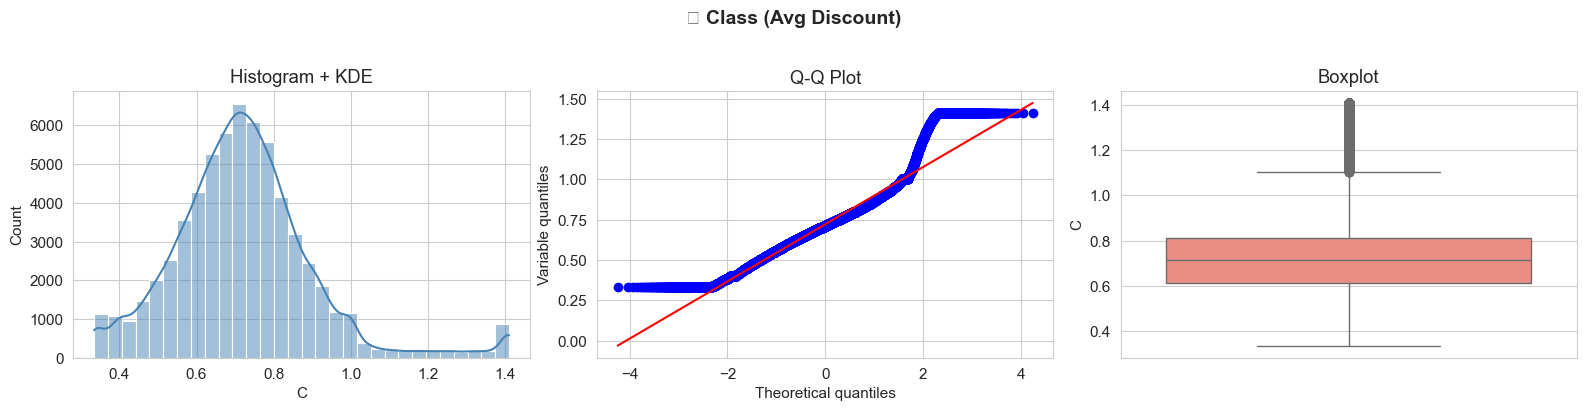

In [11]:
print('📈 Distribusi Data SETELAH Outlier Capping:')
check_plot(df_lrfmc_capped, cek_kolom)

Bisa diliaht memang tidak sepenuhnya hilang dan itu yang kita inginkan, jika terlalu ekstrim memangkasnya justru kita akan kehilangan data yang kita butuhkan

### 2.2 Correlation Heatmap

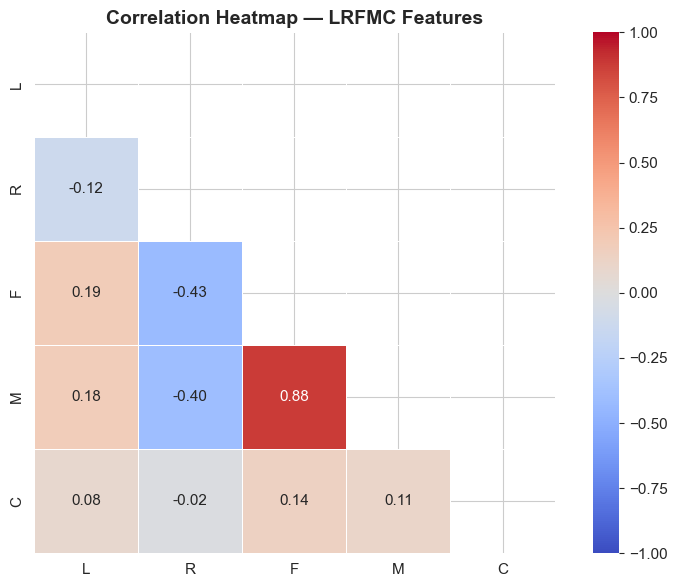

In [12]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df_lrfmc_capped.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — LRFMC Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Pairplot

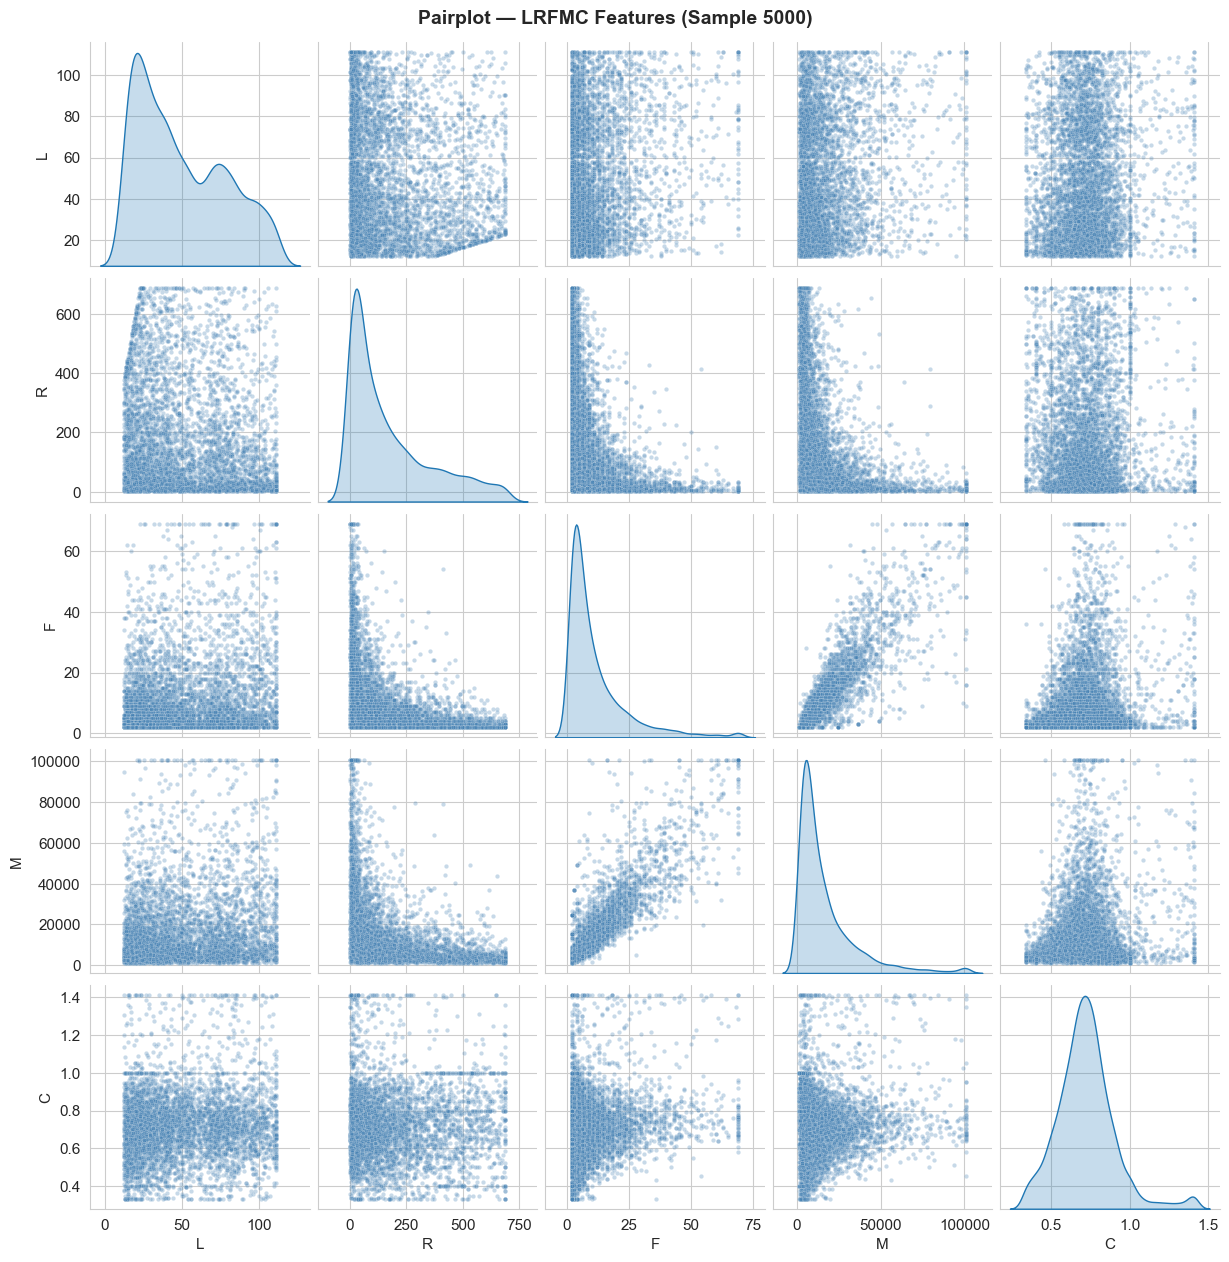

In [13]:
# Pairplot (sampling agar lebih cepat)
sample = df_lrfmc_capped.sample(n=min(5000, len(df_lrfmc_capped)), random_state=42)
g = sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10, 'color': 'steelblue'})
g.figure.suptitle('Pairplot — LRFMC Features (Sample 5000)', fontsize=14, fontweight='bold', y=1.01)
plt.show()

Berdasarkan heatmap dan pairplot kita dapat mengetahui bahwa:
- **F dan M** memiliki korelasi positif yang cukup kuat — masuk akal karena semakin sering terbang, semakin banyak KM yang ditempuh.
- **L dan F/M** berkorelasi positif — member yang lebih lama cenderung lebih sering terbang dan lebih banyak KM.
- **R** berkorelasi negatif dengan F dan M — customer yang sudah lama tidak terbang (R tinggi) cenderung punya frequency dan monetary rendah.
- **C (discount)** berkorelasi lemah dengan fitur lain — ini informasi independen yang bagus untuk segmentasi.

---
## 3. Clustering dengan K-Means (sklearn)

### Mengapa perlu Scaling?
Fitur-fitur LRFMC memiliki **skala yang sangat berbeda**:
- L: 0-100an (bulan)
- R: 1-700an (hari)
- F: 2-200an (kali)
- M: ratusan - ratusan ribu (KM)
- C: 0-1.5 (rasio diskon)

Tanpa scaling, fitur dengan skala besar (M) akan mendominasi perhitungan jarak Euclidean, membuat fitur dengan skala kecil (C) hampir tidak berpengaruh. **StandardScaler** men-standardisasi semua fitur ke mean=0 dan std=1 sehingga semua fitur punya kontribusi yang setara.

In [14]:
# Scaling data menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_lrfmc_capped)

X_scaled_df = pd.DataFrame(X_scaled, columns=df_lrfmc_capped.columns)
print('=== Data Setelah Scaling ===')
print(f'Mean per fitur (harusnya ~0):')
print(X_scaled_df.mean().round(4))
print(f'\nStd per fitur (harusnya ~1):')
print(X_scaled_df.std().round(4))
X_scaled_df.head()

=== Data Setelah Scaling ===
Mean per fitur (harusnya ~0):
L    0.0
R   -0.0
F   -0.0
M    0.0
C    0.0
dtype: float64

Std per fitur (harusnya ~1):
L    1.0
R    1.0
F    1.0
M    1.0
C    1.0
dtype: float64


,L,R,F,M,C
0,1.444108,-0.954426,4.478195,4.528994,1.315308
1,1.315244,-0.921690,4.478195,4.528994,2.908085
2,1.336525,-0.899866,4.478195,4.528994,2.921023
3,0.665013,-0.430653,0.887712,4.528994,2.023436
4,0.391915,-0.932602,4.478195,4.528994,1.364728


### 3.1 Menentukan Jumlah Cluster Optimal


In [15]:
# Elbow Method + Silhouette Score
K_range = range(2, 11)
inertias = []
silhouette_scores = []

print('Menghitung untuk K=2 hingga K=10...')
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f'  K={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={sil:.4f}')

print('\n✅ Selesai!')

Menghitung untuk K=2 hingga K=10...
  K=2: Inertia=224,161, Silhouette=0.3653
  K=3: Inertia=178,987, Silhouette=0.2653
  K=4: Inertia=146,296, Silhouette=0.2694
  K=5: Inertia=128,814, Silhouette=0.2712
  K=6: Inertia=114,766, Silhouette=0.2660
  K=7: Inertia=104,477, Silhouette=0.2416
  K=8: Inertia=97,206, Silhouette=0.2305
  K=9: Inertia=90,308, Silhouette=0.2330
  K=10: Inertia=84,640, Silhouette=0.2364

✅ Selesai!


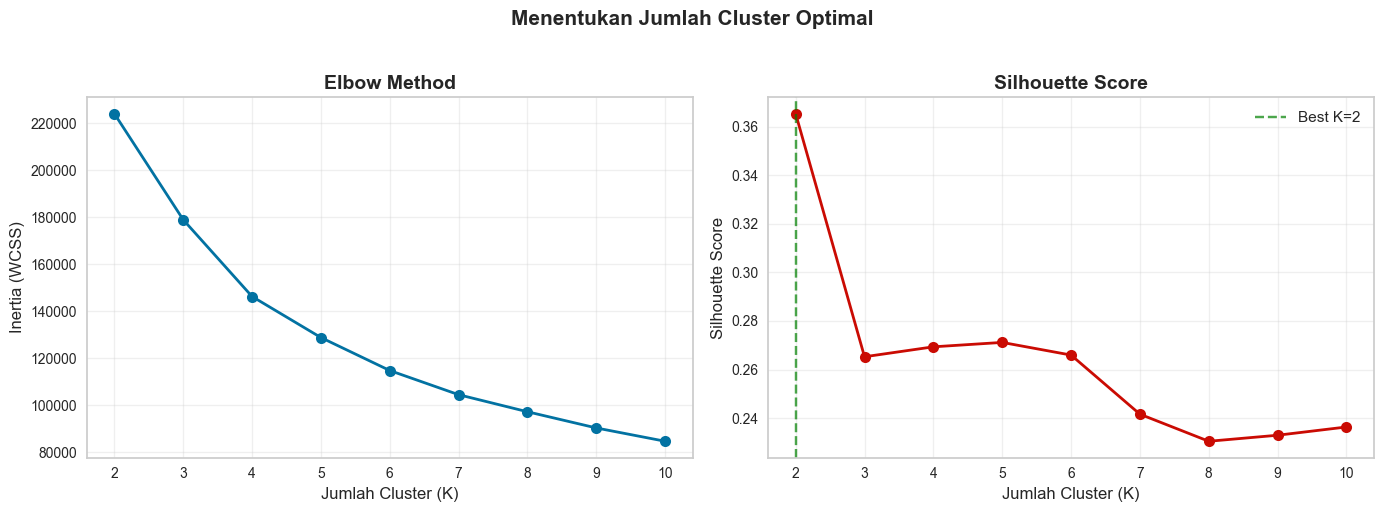

In [32]:
# Plot Elbow Method dan Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

# Highlight best silhouette
best_k_idx = np.argmax(silhouette_scores)
best_k = list(K_range)[best_k_idx]
axes[1].axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[1].legend(fontsize=11)

plt.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Pemilihan K=5 sebagai Jumlah Cluster Optimal

Meskipun Silhouette Score menunjukkan K=2 sebagai nilai tertinggi (0.365), **kita tidak bisa langsung menggunakan K=2 untuk segmentasi bisnis**. Berikut alasan lengkapnya:

#### Mengapa K=2 Tidak Cocok untuk Segmentasi Bisnis?
- Hanya 2 cluster berarti kita hanya membagi pelanggan menjadi **"aktif" vs "tidak aktif"** — ini terlalu kasar dan tidak memberikan insight yang actionable bagi tim marketing.
- Segmentasi yang bermakna memerlukan granularitas lebih tinggi agar setiap segmen bisa mendapatkan **strategi campaign yang spesifik**.

#### Analisis Elbow Method
- Dari K=2 ke K=3, penurunan inertia sangat besar → cluster masih terlalu umum.
- Dari K=3 ke K=4, penurunan inertia masih cukup signifikan.
- **Dari K=4 ke K=5**, penurunan inertia masih terlihat (~17.000), menunjukkan bahwa penambahan cluster ke-5 masih memberikan informasi baru yang bermakna.
- **Setelah K=5**, penurunan inertia mulai melandai (diminishing returns), artinya penambahan cluster berikutnya tidak banyak menambah kualitas segmentasi.
- "Siku" (elbow) paling jelas berada di sekitar **K=4–5**.

#### Analisis Silhouette Score
- K=2: **0.365** (tertinggi, tapi terlalu kasar untuk segmentasi).
- K=4: **0.2694** dan K=5: **0.2712** — keduanya hampir sama, tetapi K=5 sedikit lebih tinggi.
- Setelah K=5, silhouette score terus menurun → artinya cluster mulai terlalu kecil dan overlap.

#### Kesimpulan: K=5
Berdasarkan kombinasi Elbow Method dan Silhouette Score, serta pertimbangan bisnis bahwa segmentasi pelanggan maskapai memerlukan minimal 4–5 segmen agar actionable, **kita memilih K=5** sebagai jumlah cluster optimal.

Dengan 5 cluster, kita bisa mengidentifikasi segmen seperti: *High-Value Loyal*, *Potential Loyalist*, *At Risk*, *Low Engagement*, dan *Discount Seeker* — masing-masing dengan strategi campaign yang berbeda.

### 3.2 Fit K-Means dengan Optimal K (sklearn)

In [17]:
# Fit KMeans dengan optimal K
optimal_k = 5  # Dipilih berdasarkan analisis Elbow + Silhouette + kebutuhan bisnis
print(f'🔧 Fitting K-Means dengan K={optimal_k}...')

kmeans_sklearn = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df_lrfmc_capped['Cluster_sklearn'] = kmeans_sklearn.fit_predict(X_scaled)

sil_sklearn = silhouette_score(X_scaled, df_lrfmc_capped['Cluster_sklearn'])
print(f'\n✅ K-Means sklearn berhasil!')
print(f'   Silhouette Score: {sil_sklearn:.4f}')
print(f'   Inertia: {kmeans_sklearn.inertia_:,.0f}')
print(f'\n📊 Distribusi Cluster:')
cluster_counts = df_lrfmc_capped['Cluster_sklearn'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f'   Cluster {cluster}: {count:,} ({count/len(df_lrfmc_capped)*100:.1f}%)')

🔧 Fitting K-Means dengan K=5...

✅ K-Means sklearn berhasil!
   Silhouette Score: 0.2712
   Inertia: 128,814

📊 Distribusi Cluster:
   Cluster 0: 15,121 (24.0%)
   Cluster 1: 23,343 (37.1%)
   Cluster 2: 5,838 (9.3%)
   Cluster 3: 6,518 (10.3%)
   Cluster 4: 12,168 (19.3%)


---
## 4. Clustering dengan K-Means (PyCaret)

Sekarang kita akan membandingkan hasil dari sklearn dengan PyCaret. PyCaret menyediakan interface yang lebih mudah dan otomatis untuk clustering.

In [18]:
# PyCaret Clustering
from pycaret.clustering import *

# Setup PyCaret - gunakan data LRFMC yang sudah di-cap (tanpa kolom cluster sklearn)
df_pycaret = df_lrfmc_capped[['L', 'R', 'F', 'M', 'C']].copy()

print('🔧 Setting up PyCaret...')
setup_clustering = setup(
    data=df_pycaret,
    normalize=True,
    session_id=42,
    verbose=False
)
print('✅ PyCaret setup complete!')

🔧 Setting up PyCaret...
✅ PyCaret setup complete!


In [19]:
# Create KMeans model via PyCaret dengan jumlah cluster yang sama
print(f'🔧 Creating K-Means model dengan K={optimal_k} via PyCaret...')
kmeans_pycaret = create_model('kmeans', num_clusters=optimal_k)
print('\n✅ PyCaret K-Means model created!')

🔧 Creating K-Means model dengan K=5 via PyCaret...


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2702,22751.3389,1.1320,0,0,0



✅ PyCaret K-Means model created!


In [20]:
# Assign cluster labels ke data
df_pycaret_result = assign_model(kmeans_pycaret)
df_lrfmc_capped['Cluster_pycaret'] = df_pycaret_result['Cluster'].str.extract(r'(\d+)').astype(int).values

print('📊 Distribusi Cluster (PyCaret):')
pycaret_counts = df_lrfmc_capped['Cluster_pycaret'].value_counts().sort_index()
for cluster, count in pycaret_counts.items():
    print(f'   Cluster {cluster}: {count:,} ({count/len(df_lrfmc_capped)*100:.1f}%)')

📊 Distribusi Cluster (PyCaret):
   Cluster 0: 15,078 (23.9%)
   Cluster 1: 6,084 (9.7%)
   Cluster 2: 6,522 (10.4%)
   Cluster 3: 23,163 (36.8%)
   Cluster 4: 12,141 (19.3%)


In [21]:
# Silhouette Score PyCaret
sil_pycaret = silhouette_score(X_scaled, df_lrfmc_capped['Cluster_pycaret'])
print(f'\n=== Perbandingan Silhouette Score ===')
print(f'  sklearn K-Means:  {sil_sklearn:.4f}')
print(f'  PyCaret K-Means:  {sil_pycaret:.4f}')
print(f'\n  Selisih: {abs(sil_sklearn - sil_pycaret):.4f}')
if sil_sklearn >= sil_pycaret:
    print(f'  ✅ sklearn sedikit lebih baik atau sama')
else:
    print(f'  ✅ PyCaret sedikit lebih baik atau sama')


=== Perbandingan Silhouette Score ===
  sklearn K-Means:  0.2712
  PyCaret K-Means:  0.2702

  Selisih: 0.0009
  ✅ sklearn sedikit lebih baik atau sama


**Insight:** Kedua model (sklearn dan PyCaret) menggunakan algoritma K-Means yang sama, sehingga perbedaan hasilnya biasanya minimal. Perbedaan kecil bisa terjadi karena perbedaan inisialisasi random seed atau implementasi normalisasi. Untuk analisis selanjutnya, kita akan menggunakan **hasil dari sklearn** sebagai model utama.

---
## 5. Visualisasi Hasil Clustering

Kita akan memvisualisasikan cluster menggunakan beberapa metode:
1. **PCA 2D Scatter Plot** — proyeksi data ke 2 dimensi
2. **Radar Chart** — profil rata-rata per cluster
3. **Bar Chart** — perbandingan fitur per cluster
4. **Cluster Size** — distribusi ukuran cluster

### 5.1 PCA 2D Scatter Plot

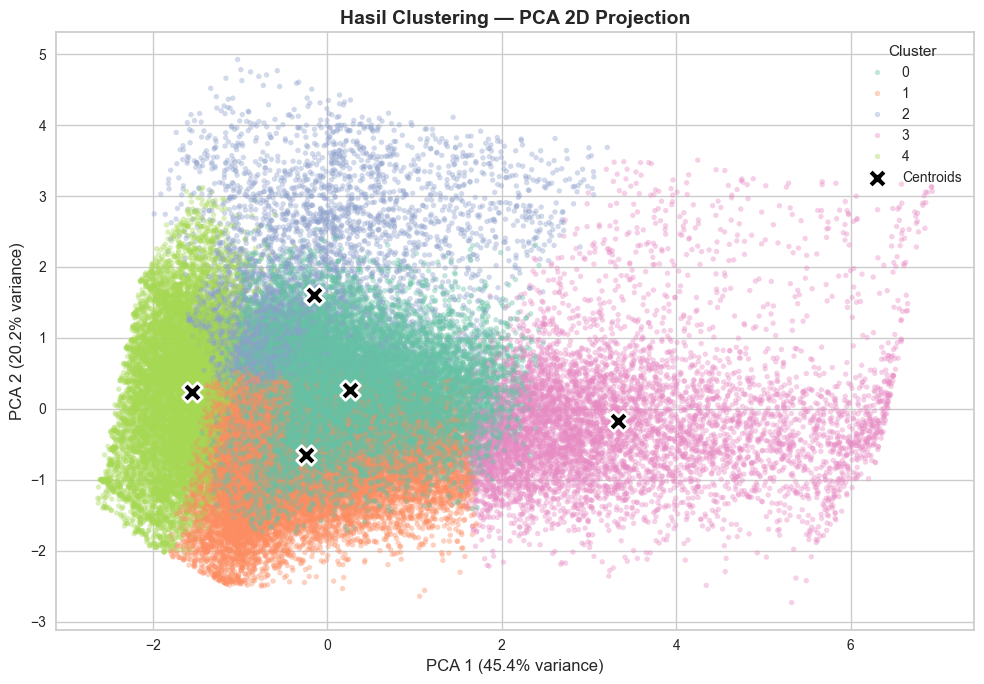


📊 Total variance explained oleh 2 komponen PCA: 65.5%


In [22]:
# PCA untuk reduksi dimensi ke 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_lrfmc_capped['PCA1'] = X_pca[:, 0]
df_lrfmc_capped['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
palette = sns.color_palette('Set2', optimal_k)
scatter = sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster_sklearn',
    data=df_lrfmc_capped,
    palette=palette,
    alpha=0.4, s=15, edgecolor='none'
)

# Plot centroids
centroids_pca = pca.transform(kmeans_sklearn.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, edgecolors='white', linewidths=2,
            label='Centroids', zorder=5)

plt.title('Hasil Clustering — PCA 2D Projection', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.legend(title='Cluster', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()

total_var = sum(pca.explained_variance_ratio_) * 100
print(f'\n📊 Total variance explained oleh 2 komponen PCA: {total_var:.1f}%')

### 5.2 Radar Chart (Spider Chart) per Cluster

Radar chart membantu kita melihat **profil** tiap cluster dalam semua dimensi LRFMC sekaligus.

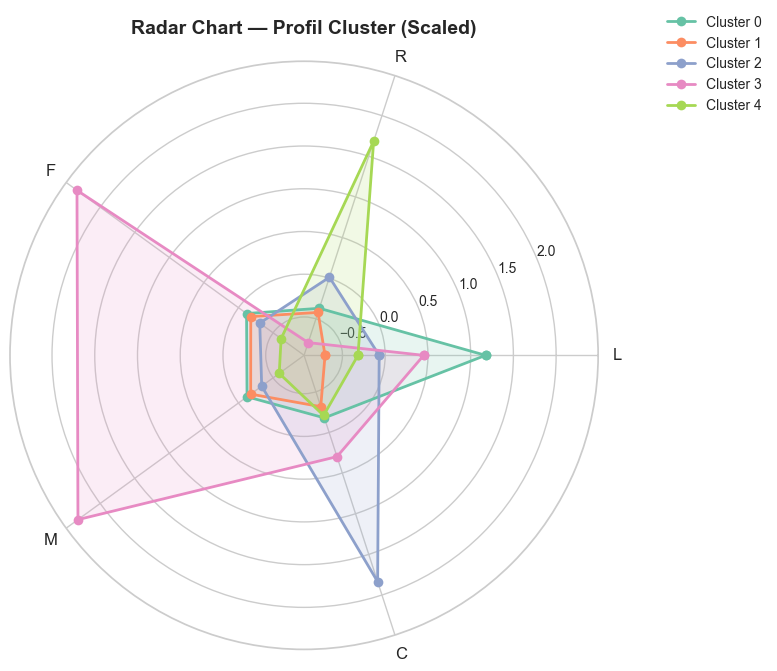

In [23]:
# Hitung rata-rata per cluster (menggunakan data yang sudah di-scale agar scale seragam)
cluster_means_scaled = pd.DataFrame(X_scaled, columns=['L', 'R', 'F', 'M', 'C'])
cluster_means_scaled['Cluster'] = df_lrfmc_capped['Cluster_sklearn'].values
cluster_profile_scaled = cluster_means_scaled.groupby('Cluster').mean()

# Radar Chart
categories = list(cluster_profile_scaled.columns)
N = len(categories)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = sns.color_palette('Set2', optimal_k)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the circle

for idx, (cluster, row) in enumerate(cluster_profile_scaled.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=palette[idx])
    ax.fill(angles, values, alpha=0.15, color=palette[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title('Radar Chart — Profil Cluster (Scaled)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

### 5.3 Bar Chart Rata-rata LRFMC per Cluster

=== Rata-rata LRFMC per Cluster ===


,L,R,F,M,C
Cluster_sklearn,,,,,
0,82.61,108.12,10.13,14454.31,0.69
1,29.65,98.84,9.35,13480.15,0.66
2,47.51,178.12,7.68,10523.16,1.06
3,62.19,30.70,41.55,59851.94,0.78
4,40.52,484.85,3.73,5816.26,0.68


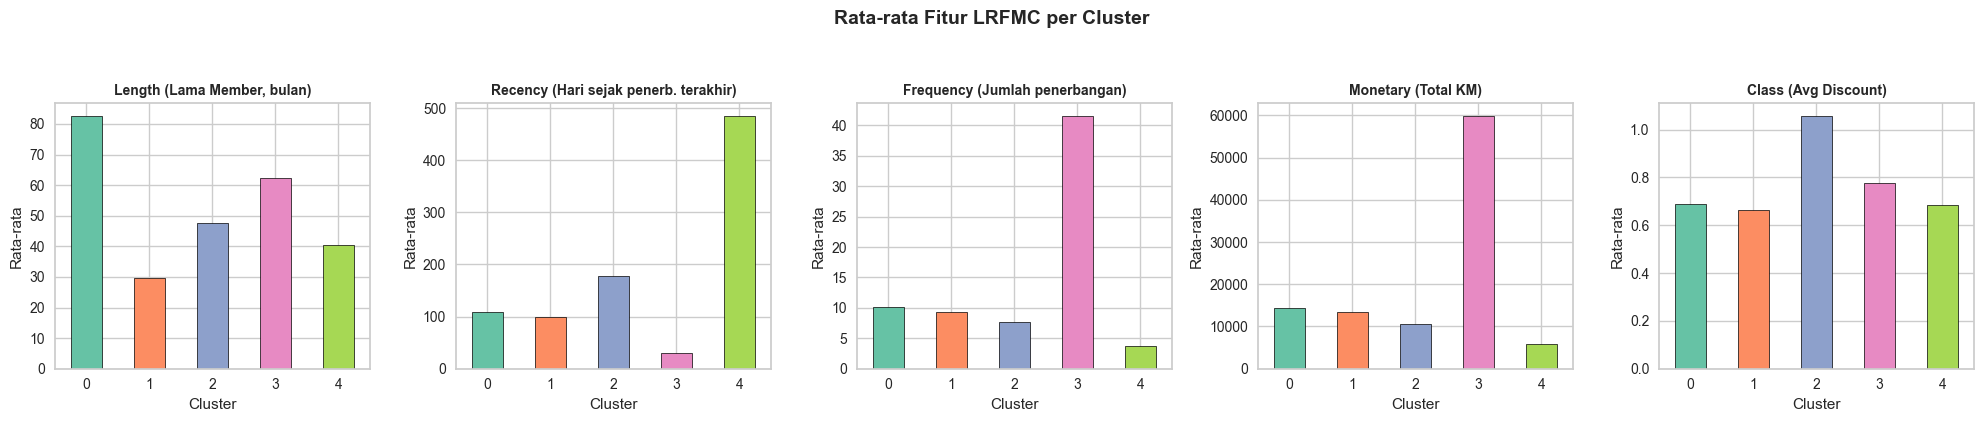

In [24]:
# Rata-rata per cluster (data asli, bukan scaled)
cluster_profile_raw = df_lrfmc_capped.groupby('Cluster_sklearn')[['L', 'R', 'F', 'M', 'C']].mean()
print('=== Rata-rata LRFMC per Cluster ===')
display(cluster_profile_raw.round(2))

# Bar chart per fitur
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
palette = sns.color_palette('Set2', optimal_k)

for i, col in enumerate(['L', 'R', 'F', 'M', 'C']):
    cluster_profile_raw[col].plot(
        kind='bar', ax=axes[i], color=palette, edgecolor='black', linewidth=0.5
    )
    axes[i].set_title(f'{nama_fitur[col]}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Rata-rata')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Rata-rata Fitur LRFMC per Cluster', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 5.4 Distribusi Ukuran Cluster

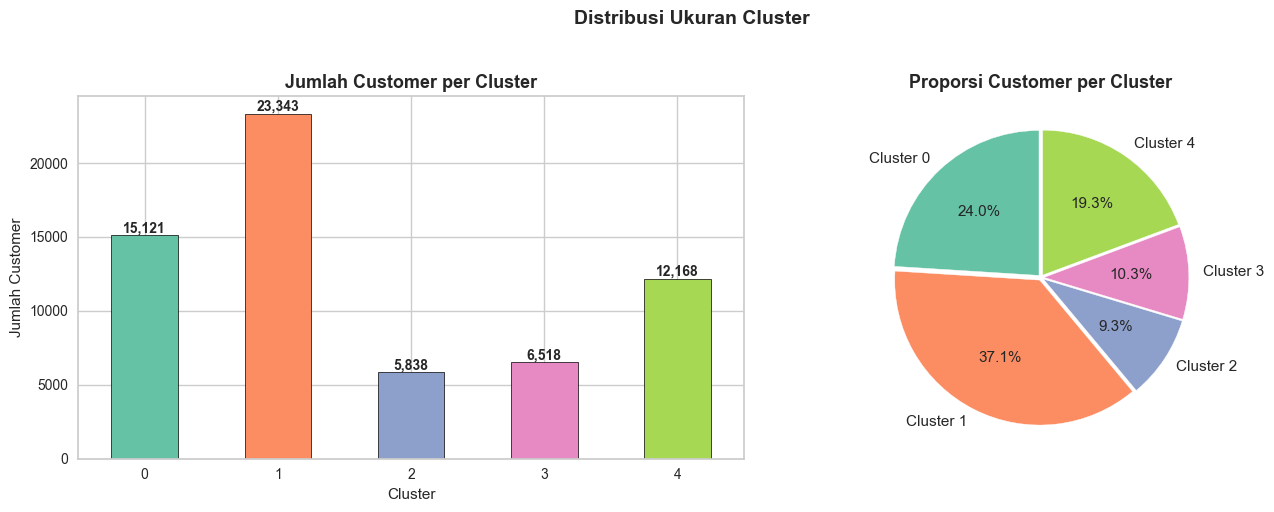

In [25]:
# Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_counts = df_lrfmc_capped['Cluster_sklearn'].value_counts().sort_index()
palette = sns.color_palette('Set2', optimal_k)

# Bar chart
cluster_counts.plot(kind='bar', ax=axes[0], color=palette, edgecolor='black', linewidth=0.5)
axes[0].set_title('Jumlah Customer per Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Jumlah Customer')
axes[0].tick_params(axis='x', rotation=0)
for i, (cluster, count) in enumerate(cluster_counts.items()):
    axes[0].text(i, count + 200, f'{count:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(cluster_counts, labels=[f'Cluster {c}' for c in cluster_counts.index],
            autopct='%1.1f%%', colors=palette, startangle=90, explode=[0.02]*optimal_k,
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Customer per Cluster', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Ukuran Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Evaluasi Model

### 6.1 Perbandingan Silhouette Score untuk Berbagai K

In [26]:
# Tabel evaluasi untuk berbagai K
eval_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})
eval_df['Inertia Reduction (%)'] = eval_df['Inertia'].pct_change().apply(lambda x: f'{x*100:.1f}%' if pd.notnull(x) else '-')
eval_df['Silhouette Score'] = eval_df['Silhouette Score'].round(4)
eval_df['Inertia'] = eval_df['Inertia'].apply(lambda x: f'{x:,.0f}')

print('=== Evaluasi K-Means untuk K=2 s/d K=10 ===')
eval_df

=== Evaluasi K-Means untuk K=2 s/d K=10 ===


,K,Inertia,Silhouette Score,Inertia Reduction (%)
0,2,"224,161",0.3653,-
1,3,"178,987",0.2653,-20.2%
2,4,"146,296",0.2694,-18.3%
3,5,"128,814",0.2712,-11.9%
4,6,"114,766",0.2660,-10.9%
5,7,"104,477",0.2416,-9.0%
6,8,"97,206",0.2305,-7.0%
7,9,"90,308",0.2330,-7.1%
8,10,"84,640",0.2364,-6.3%


### 6.2 Perbandingan sklearn vs PyCaret

In [27]:
# Perbandingan detail sklearn vs PyCaret
comparison = pd.DataFrame({
    'Metrik': ['Jumlah Cluster (K)', 'Silhouette Score', 'Inertia'],
    'sklearn K-Means': [optimal_k, round(sil_sklearn, 4), f'{kmeans_sklearn.inertia_:,.0f}'],
    'PyCaret K-Means': [optimal_k, round(sil_pycaret, 4), '-']
})

print('=== Perbandingan Model: sklearn vs PyCaret ===')
display(comparison)

# Cluster distribution comparison
print('\n=== Distribusi Cluster ===')
dist_comp = pd.DataFrame({
    'Cluster': range(optimal_k),
    'sklearn Count': [cluster_counts[i] for i in range(optimal_k)],
    'sklearn %': [f"{cluster_counts[i]/len(df_lrfmc_capped)*100:.1f}%" for i in range(optimal_k)],
    'PyCaret Count': [pycaret_counts[i] for i in range(optimal_k)],
    'PyCaret %': [f"{pycaret_counts[i]/len(df_lrfmc_capped)*100:.1f}%" for i in range(optimal_k)]
})
dist_comp

=== Perbandingan Model: sklearn vs PyCaret ===


,Metrik,sklearn K-Means,PyCaret K-Means
0,Jumlah Cluster (K),5,5
1,Silhouette Score,0.2712,0.2702
2,Inertia,"128,814",-



=== Distribusi Cluster ===


,Cluster,sklearn Count,sklearn %,PyCaret Count,PyCaret %
0,0,15121,24.0%,15078,23.9%
1,1,23343,37.1%,6084,9.7%
2,2,5838,9.3%,6522,10.4%
3,3,6518,10.3%,23163,36.8%
4,4,12168,19.3%,12141,19.3%


---
## 7. Insight dan Rekomendasi Bisnis

### 7.1 Profiling Setiap Cluster

In [28]:
# Profiling detail per cluster
print('=== Profil Detail Setiap Cluster ===')
print('(Menggunakan data LRFMC asli setelah outlier capping)\n')

profile = df_lrfmc_capped.groupby('Cluster_sklearn')[['L', 'R', 'F', 'M', 'C']].agg(['mean', 'median', 'std']).round(2)
display(profile)

print('\n=== Rata-rata LRFMC per Cluster (Ringkasan) ===')
cluster_summary = df_lrfmc_capped.groupby('Cluster_sklearn')[['L', 'R', 'F', 'M', 'C']].mean().round(2)
cluster_summary['Jumlah'] = df_lrfmc_capped['Cluster_sklearn'].value_counts().sort_index()
cluster_summary['Persentase'] = (cluster_summary['Jumlah'] / len(df_lrfmc_capped) * 100).round(1)
display(cluster_summary)

=== Profil Detail Setiap Cluster ===
(Menggunakan data LRFMC asli setelah outlier capping)



L                     R                     F         \
                  mean median    std    mean median     std   mean median   
Cluster_sklearn                                                             
0                82.61  81.53  14.98  108.12   80.0   99.13  10.13    8.0   
1                29.65  27.80  12.41   98.84   78.0   82.20   9.35    8.0   
2                47.51  43.30  25.06  178.12  153.0  144.38   7.68    5.0   
3                62.19  61.47  28.24   30.70   14.0   46.50  41.55   38.0   
4                40.52  33.35  22.92  484.85  482.0  117.13   3.73    3.0   

                               M                        C               
                   std      mean   median       std  mean median   std  
Cluster_sklearn                                                         
0                 6.99  14454.31  11959.0  10175.00  0.69   0.70  0.13  
1                 6.56  13480.15  10787.0   9840.45  0.66   0.68  0.12  
2                 6.53  10523.16   6956.0   9886.27  1.06   0.98  0.18  
3                14.78  59851.94  54355.0  21071.83  0.78   0.75  0.16  
4                 2.61   5816.26   4251.0   4978.36  0.68   0.70  0.17


=== Rata-rata LRFMC per Cluster (Ringkasan) ===


,L,R,F,M,C,Jumlah,Persentase
Cluster_sklearn,,,,,,,
0,82.61,108.12,10.13,14454.31,0.69,15121,24.0
1,29.65,98.84,9.35,13480.15,0.66,23343,37.1
2,47.51,178.12,7.68,10523.16,1.06,5838,9.3
3,62.19,30.70,41.55,59851.94,0.78,6518,10.3
4,40.52,484.85,3.73,5816.26,0.68,12168,19.3


Ini sekarang kita petakan statusnya menggunakn z-score

In [48]:
# Hitung Z-score per fitur di tiap cluster
cluster_means = df_lrfmc_capped.groupby('Cluster_sklearn')[['L', 'R', 'F', 'M', 'C']].mean()
overall_mean = df_lrfmc_capped[['L', 'R', 'F', 'M', 'C']].mean()
overall_std = df_lrfmc_capped[['L', 'R', 'F', 'M', 'C']].std()

# Hitung Z-Score: (Mean_Cluster - Mean_Total) / Std_Total
z_scores = (cluster_means - overall_mean) / overall_std

for cluster in z_scores.index:
    count = (df_lrfmc_capped['Cluster_sklearn'] == cluster).sum()
    pct = count / len(df_lrfmc_capped) * 100
    
    print(f'\n--- Cluster {cluster} ({count:,} customers, {pct:.1f}%) ---')
    for feat in z_scores.columns:
        # Ambil nilai asli (rata-rata cluster)
        val = cluster_means.loc[cluster, feat] 
        # Ambil nilai z-score
        z = z_scores.loc[cluster, feat]
        
        # Pake threshold 0.5 standard deviation
        status = '🔺 TINGGI' if z > 0.5 else ('🔻 RENDAH' if z < -0.5 else '➖ SEDANG')
        
        # Tambahkan {val:.2f} di dalam print
        print(f"  {feat}, {nama_fitur[feat]}: {val:.2f} | {status} (Z-score: {z:.2f})")



--- Cluster 0 (15,121 customers, 24.0%) ---
  L, Length (Lama Member, bulan): 82.61 | 🔺 TINGGI (Z-score: 1.17)
  R, Recency (Hari sejak penerb. terakhir): 108.12 | ➖ SEDANG (Z-score: -0.37)
  F, Frequency (Jumlah penerbangan): 10.13 | ➖ SEDANG (Z-score: -0.12)
  M, Monetary (Total KM): 14454.31 | ➖ SEDANG (Z-score: -0.12)
  C, Class (Avg Discount): 0.69 | ➖ SEDANG (Z-score: -0.18)

--- Cluster 1 (23,343 customers, 37.1%) ---
  L, Length (Lama Member, bulan): 29.65 | 🔻 RENDAH (Z-score: -0.70)
  R, Recency (Hari sejak penerb. terakhir): 98.84 | ➖ SEDANG (Z-score: -0.42)
  F, Frequency (Jumlah penerbangan): 9.35 | ➖ SEDANG (Z-score: -0.18)
  M, Monetary (Total KM): 13480.15 | ➖ SEDANG (Z-score: -0.18)
  C, Class (Avg Discount): 0.66 | ➖ SEDANG (Z-score: -0.32)

--- Cluster 2 (5,838 customers, 9.3%) ---
  L, Length (Lama Member, bulan): 47.51 | ➖ SEDANG (Z-score: -0.07)
  R, Recency (Hari sejak penerb. terakhir): 178.12 | ➖ SEDANG (Z-score: 0.01)
  F, Frequency (Jumlah penerbangan): 7.68 

### 7.2 Ringkasan & Rekomendasi Bisnis

Berdasarkan profil LRFMC di atas dengan **K=5 cluster**, berikut adalah framework rekomendasi untuk setiap tipe segmen pelanggan maskapai:

| Cluster | Tipe Segmen | Karakteristik LRFMC | Strategi Campaign |
|:---:|---|---|---|
| 0 | **The Veterans** | L tinggi, R sedang, F sedang, M sedang, C sedang | **Retain**: loyalty rewards eksklusif, early access, upgrade seat atau bagasi gratis|
| 1 | **The Newbies** | L rendah, R sedang, F sedang, M sedang C sedang| **Grow**: welcome bonus, cross-sell rute baru, bundle deals, program earning miles, referral bonus |
| 2 | **The Discount Hunters** | L sedang, R sedang, F sedang, M sedang, C tinggi | **Monetize**: berikan diskon yang dikontrol seperti promo Limited Time Offer, diskon tengah malem, atau diskon untuk rute tertentu. Berikan bundling (harga normal tapi berikan bonus seperti bagasi/meal) |
| 3 | **The Sultans** | L sedang, R rendah, F tinggi, M tinggi, C sedang | **Activate**: Kasih akses Lounge, Priority Check-in/Boarding, intinya pelayanan lebih diprioritaskan |
| 4 | **The Zombies** | L sedang, R tinggi, F rendah, M rendah, C tinggi | **Win-back**: reminder email, diskon besar khusus, pelajari rute terfavorite untuk penawaran, pelajari kenapa churn dan evaluasi |

| Segmen | Size (%) | Urgensi | Value |
|---|---|---|---|
| Cluster 1 (The Newbies) | 37.1% | ⭐⭐⭐ | Masa Depan |
| Cluster 0 (The Veterans) | 24.0% | ⭐⭐ | Fondasi |
| Cluster 4 (The Zombies) | 19.3% | ⭐⭐ | Low/Zero |
| Cluster 3 (The Sultans) | 10.3% | ⭐⭐⭐⭐⭐ | CASH COW |
| Cluster 2 (The Discount Hunters) | 9.3% | ⭐ | Margin Tipis |


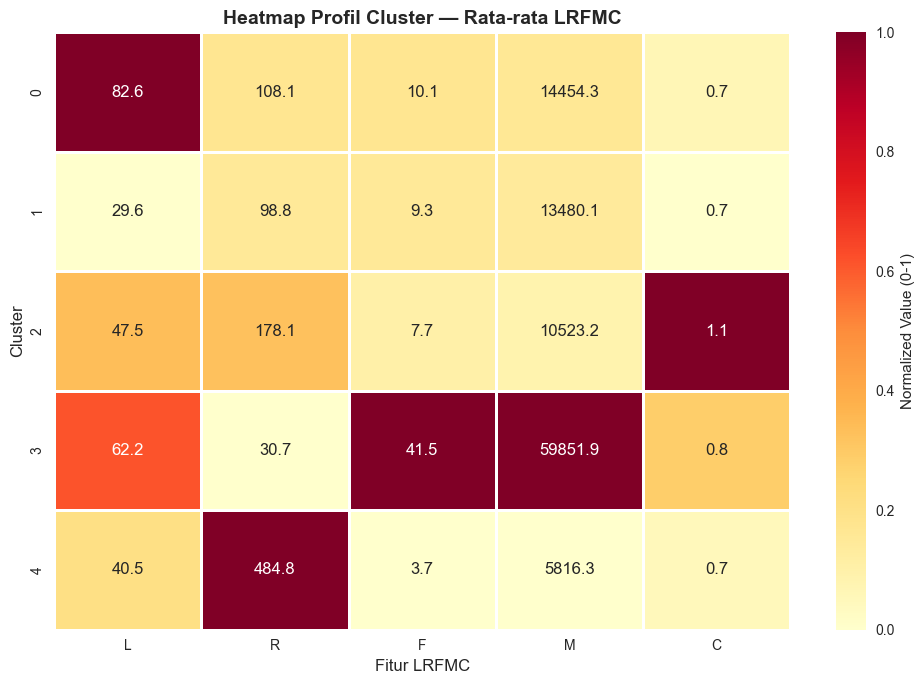

In [30]:
# Visualisasi final: Heatmap profil cluster (normalized)
plt.figure(figsize=(10, optimal_k + 2))

# Normalize means per fitur (0-1) agar bisa dibandingkan
means_norm = means.copy()
for col in means_norm.columns:
    means_norm[col] = (means_norm[col] - means_norm[col].min()) / (means_norm[col].max() - means_norm[col].min())

sns.heatmap(means_norm, annot=means.round(1).values, fmt='', cmap='YlOrRd',
            linewidths=1, linecolor='white', cbar_kws={'label': 'Normalized Value (0-1)'})
plt.title('Heatmap Profil Cluster — Rata-rata LRFMC', fontsize=14, fontweight='bold')
plt.xlabel('Fitur LRFMC', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.show()

### Kesimpulan

Jadi berdasaarkan percobaan yang kita lakukan, kita tahu bahwa dalam menentukan jumlah cluster menggunakan KNN itu tidak harus selalu berpatokan dari silhoutte score tertinggi, karena kita juga harus memperhatkan data yang kita olah dan tujuan segmentasi kita. <br>

Pada akhirnya terambil 5 cluster yang bervariasi. Untuk customer baru, member lama, dan para sultan tentu kita perlu perhatikan. Namun, untuk para zombies yang kemungkinan potensi churnnya tinggi atau malah sudah churn itu sebenernya bisa kita perhatikan jg tapi tidak terlalu difokuskan, jadi lebih ke arah evaluasi sebenernya apa penyebab mereka itu mulai meninggalkan maskapai kita gitu, maka bisa dibuat melalui churn prediction. Sementara untuk orang-orang yang hanya mencari diskon menurutku adalah prioritas terendah, karena sedari awal mereka tidak memandang maskapai kita hanya mencari diskonan saja, bisa dilakukan pendekatan diskon yang terkontrol tetapi tidak setiap saat juga.